In [1]:
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
fastf1.Cache.enable_cache('C:/Users/Manx/F1_Data_Cache')

In [5]:
session = fastf1.get_session(2025,'British','R')
session.load(telemetry=True, laps=True, weather=True)

core           INFO 	Loading data for British Grand Prix - Race [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

In [7]:
print("✅ Session loaded:", session.event['EventName'], session.date)

✅ Session loaded: British Grand Prix 2025-07-06 14:00:00


# Final Race Classification

In [10]:
results = session.results[['Position', 'Abbreviation', 'FullName', 'TeamName', 'Points', 'Status']]
results = results.sort_values('Position').reset_index(drop=True)

In [12]:
colors = [fastf1.plotting.get_team_color(team, session) for team in results['TeamName']]

req            INFO 	Using cached data for driver_info


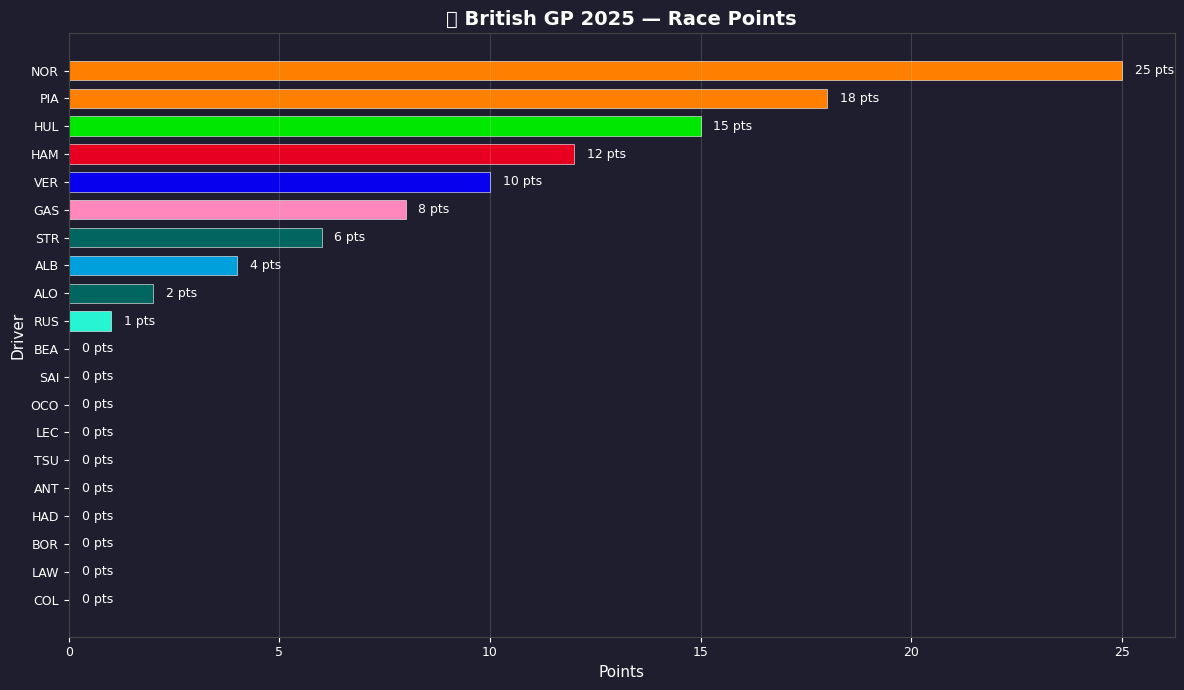

In [14]:
fig2, ax2 = plt.subplots(figsize=(12, 7))
ax2.set_facecolor('#1e1e2e')
fig2.patch.set_facecolor('#1e1e2e')

results = session.results.sort_values('Position')
bar_colors = [fastf1.plotting.get_team_color(team, session) for team in results['TeamName']]

bars2 = ax2.barh(
    results['Abbreviation'][::-1],
    results['Points'][::-1],
    color=bar_colors[::-1],
    edgecolor='white',
    linewidth=0.4,
    height=0.7
)

for bar, pts in zip(bars2, results['Points'][::-1]):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{int(pts)} pts', va='center', color='white', fontsize=9)

ax2.set_xlabel('Points', color='white', fontsize=11)
ax2.set_ylabel('Driver', color='white', fontsize=11)
ax2.set_title('🏆 British GP 2025 — Race Points', color='white', fontsize=14, fontweight='bold')
ax2.tick_params(colors='white', labelsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor('#444')
ax2.grid(axis='x', alpha=0.15, color='white')

plt.tight_layout()
plt.savefig('race_points.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

In [16]:
bar_colors = [fastf1.plotting.get_team_color(team, session) for team in results['TeamName']]
bars2 = ax2.barh(
    results['Abbreviation'][::-1],
    results['Points'][::-1],
    color=bar_colors[::-1],
    edgecolor='white',
    linewidth=0.5,
    height=0.6
)

for bar, pts in zip(bars2, results['Points'][::-1]):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{int(pts)} pts', va='center', color='white', fontsize=9)

ax2.set_xlabel('Points', color='white')
ax2.set_title('🏆 British GP 2025 — Race Points', color='white', fontsize=14, fontweight='bold')
ax2.tick_params(colors='white')
ax2.xaxis.label.set_color('white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#444')
ax2.set_xlim(0, 30)

plt.tight_layout()
plt.savefig('race_points.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print(results[['Position','Abbreviation','TeamName','Points','Status']].to_string(index=False))

<Figure size 640x480 with 0 Axes>

 Position Abbreviation        TeamName  Points        Status
      1.0          NOR         McLaren    25.0      Finished
      2.0          PIA         McLaren    18.0      Finished
      3.0          HUL     Kick Sauber    15.0      Finished
      4.0          HAM         Ferrari    12.0      Finished
      5.0          VER Red Bull Racing    10.0      Finished
      6.0          GAS          Alpine     8.0      Finished
      7.0          STR    Aston Martin     6.0      Finished
      8.0          ALB        Williams     4.0      Finished
      9.0          ALO    Aston Martin     2.0      Finished
     10.0          RUS        Mercedes     1.0      Finished
     11.0          BEA    Haas F1 Team     0.0      Finished
     12.0          SAI        Williams     0.0      Finished
     13.0          OCO    Haas F1 Team     0.0      Finished
     14.0          LEC         Ferrari     0.0      Finished
     15.0          TSU Red Bull Racing     0.0        Lapped
     16.0          ANT  

# Lap Time Evolution (Top 5 Drivers)

In [19]:
top5 = results.head(5)['Abbreviation'].tolist()
laps = session.laps.pick_drivers(top5).pick_quicklaps()

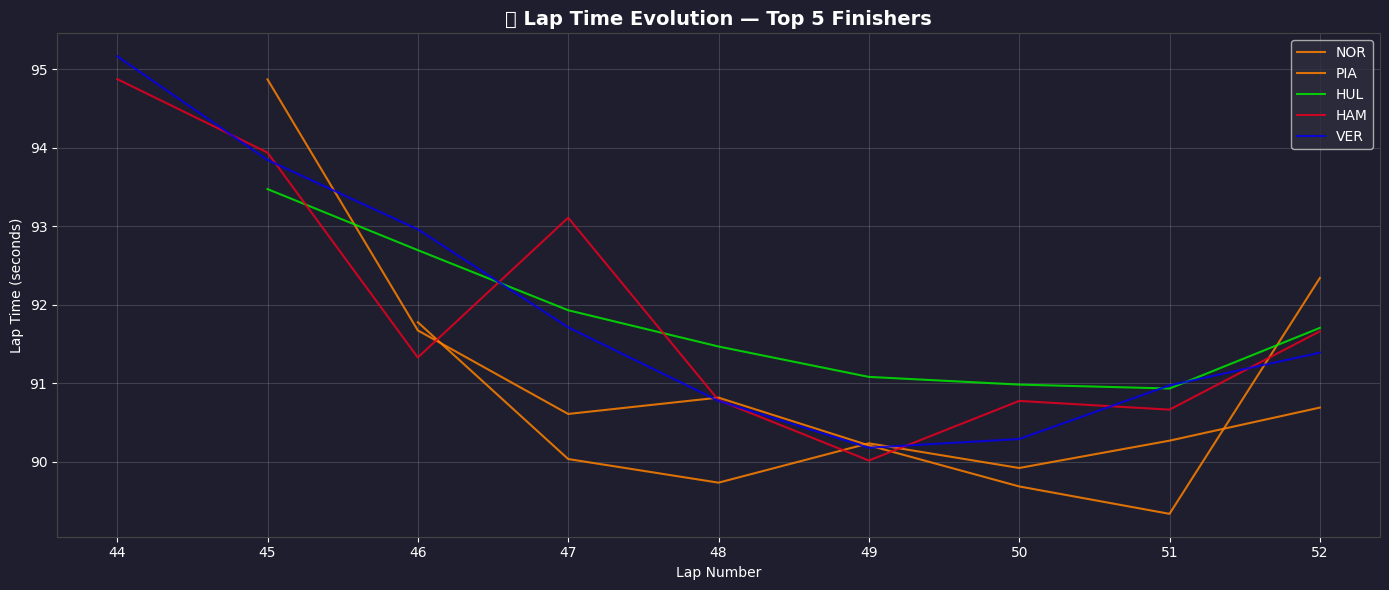

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_facecolor('#1e1e2e')
fig.patch.set_facecolor('#1e1e2e')

for driver in top5:
    d_laps = laps.pick_driver(driver)
    color = fastf1.plotting.get_driver_color(driver, session)
    lap_times_sec = d_laps['LapTime'].dt.total_seconds()
    ax.plot(d_laps['LapNumber'], lap_times_sec, label=driver, color=color, linewidth=1.5, alpha=0.85)

ax.set_xlabel('Lap Number', color='white')
ax.set_ylabel('Lap Time (seconds)', color='white')
ax.set_title('⏱️ Lap Time Evolution — Top 5 Finishers', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
ax.legend(facecolor='#2e2e3e', labelcolor='white', fontsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.grid(alpha=0.15, color='white')

plt.tight_layout()
plt.savefig('lap_times.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

# Tyre Strategy (Includes All Drivers)

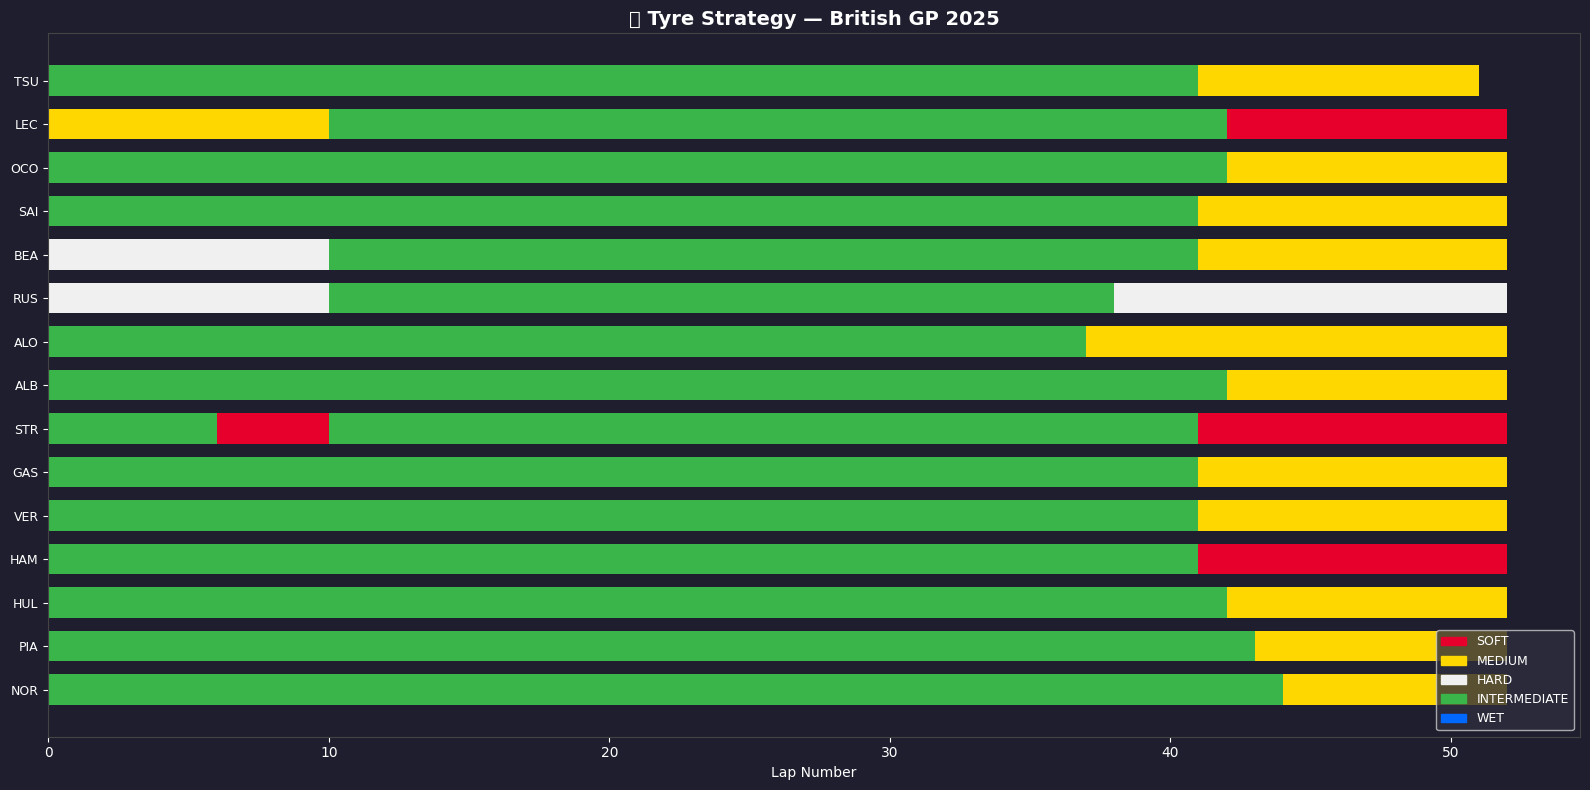

In [24]:
all_laps = session.laps
drivers = session.results.sort_values('Position')['Abbreviation'].tolist()[:15]

compound_colors = {
    'SOFT': '#e8002d',
    'MEDIUM': '#ffd700',
    'HARD': '#f0f0f0',
    'INTERMEDIATE': '#39b54a',
    'WET': '#0067ff',
    'UNKNOWN': '#888888'
}

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_facecolor('#1e1e2e')
fig.patch.set_facecolor('#1e1e2e')

for i, driver in enumerate(drivers):
    d_laps = all_laps.pick_driver(driver)
    for _, lap in d_laps.iterrows():
        compound = str(lap.get('Compound', 'UNKNOWN')).upper()
        color = compound_colors.get(compound, '#888888')
        ax.barh(i, 1, left=lap['LapNumber'] - 1, color=color, edgecolor='none', height=0.7)

ax.set_yticks(range(len(drivers)))
ax.set_yticklabels(drivers, color='white', fontsize=9)
ax.set_xlabel('Lap Number', color='white')
ax.set_title('🔵 Tyre Strategy — British GP 2025', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in compound_colors.items() if k != 'UNKNOWN']
ax.legend(handles=legend_patches, loc='lower right', facecolor='#2e2e3e', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('tyre_strategy.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

# Speed Comparison - Fastest Lap Telemetry (Top 3)

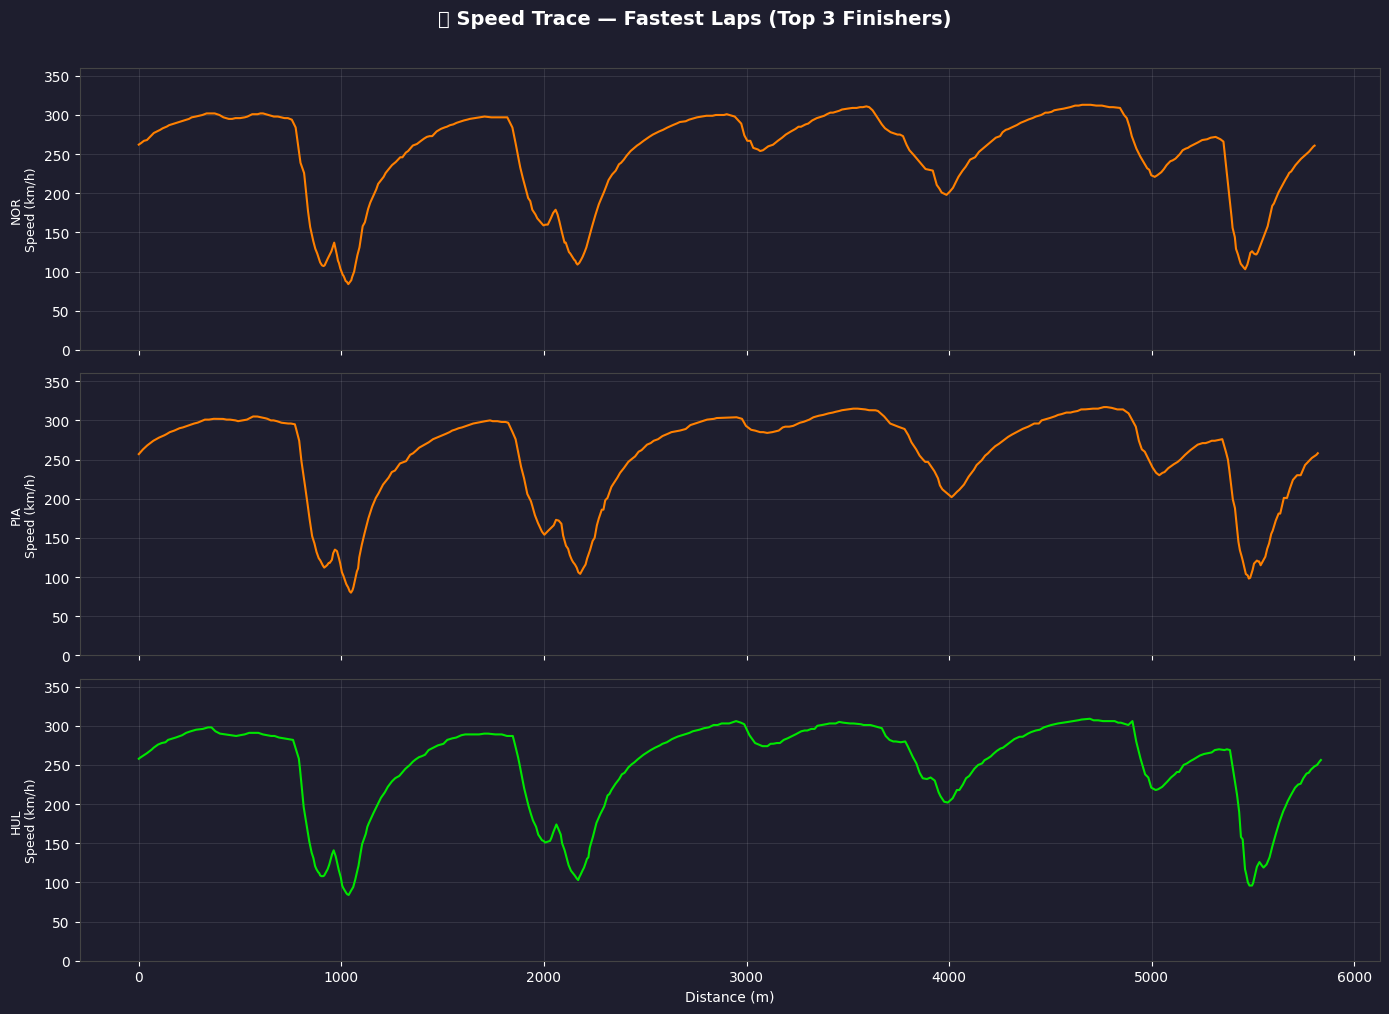

In [27]:
top3 = results.head(3)['Abbreviation'].tolist()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.patch.set_facecolor('#1e1e2e')

for ax, driver in zip(axes, top3):
    ax.set_facecolor('#1e1e2e')
    try:
        fast_lap = session.laps.pick_driver(driver).pick_fastest()
        tel = fast_lap.get_telemetry()
        color = fastf1.plotting.get_driver_color(driver, session)
        ax.plot(tel['Distance'], tel['Speed'], color=color, linewidth=1.5)
        ax.set_ylabel(f'{driver}\nSpeed (km/h)', color='white', fontsize=9)
        ax.tick_params(colors='white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444')
        ax.grid(alpha=0.1, color='white')
        ax.set_ylim(0, 360)
    except Exception as e:
        ax.text(0.5, 0.5, f'No telemetry for {driver}', transform=ax.transAxes,
                color='white', ha='center')

axes[-1].set_xlabel('Distance (m)', color='white')
fig.suptitle('🏎️ Speed Trace — Fastest Laps (Top 3 Finishers)', color='white',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('speed_telemetry.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

# Fastest Lap Per Driver

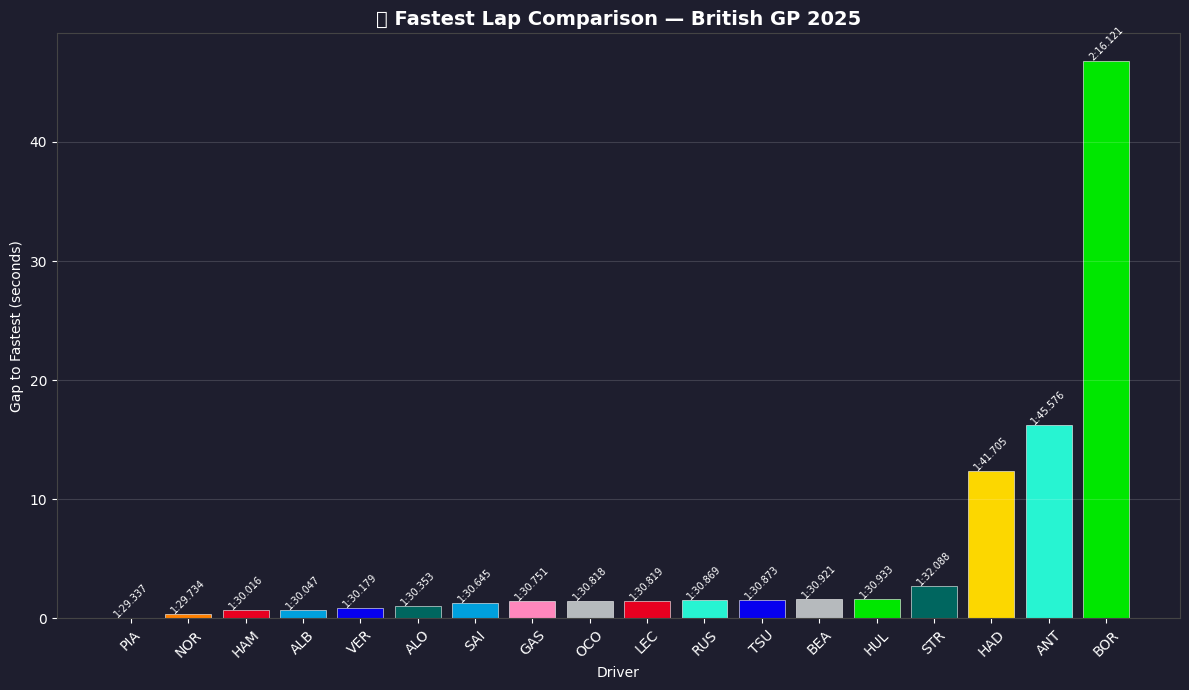

In [32]:
fastest_laps = []
for drv in results['Abbreviation']:
    try:
        fl = session.laps.pick_driver(drv).pick_fastest()
        fastest_laps.append({'Driver': drv, 'FastestLap': fl['LapTime'].total_seconds()})
    except:
        pass

fl_df = pd.DataFrame(fastest_laps).sort_values('FastestLap').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor('#1e1e2e')
fig.patch.set_facecolor('#1e1e2e')

bar_colors = []
for drv in fl_df['Driver']:
    try:
        team = results[results['Abbreviation'] == drv]['TeamName'].values[0]
        bar_colors.append(fastf1.plotting.get_team_color(team, session))
    except:
        bar_colors.append('#888')

bars = ax.bar(fl_df['Driver'], fl_df['FastestLap'] - fl_df['FastestLap'].min(),
              color=bar_colors, edgecolor='white', linewidth=0.4)

for bar, (_, row) in zip(bars, fl_df.iterrows()):
    mins = int(row['FastestLap'] // 60)
    secs = row['FastestLap'] % 60
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{mins}:{secs:05.3f}", ha='center', color='white', fontsize=7, rotation=45)

ax.set_xlabel('Driver', color='white')
ax.set_ylabel('Gap to Fastest (seconds)', color='white')
ax.set_title('📊 Fastest Lap Comparison — British GP 2025', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white', axis='x', rotation=45)
ax.tick_params(colors='white', axis='y')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.grid(axis='y', alpha=0.15, color='white')

plt.tight_layout()
plt.savefig('fastest_laps.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

# Track & Air Temperature Over Race

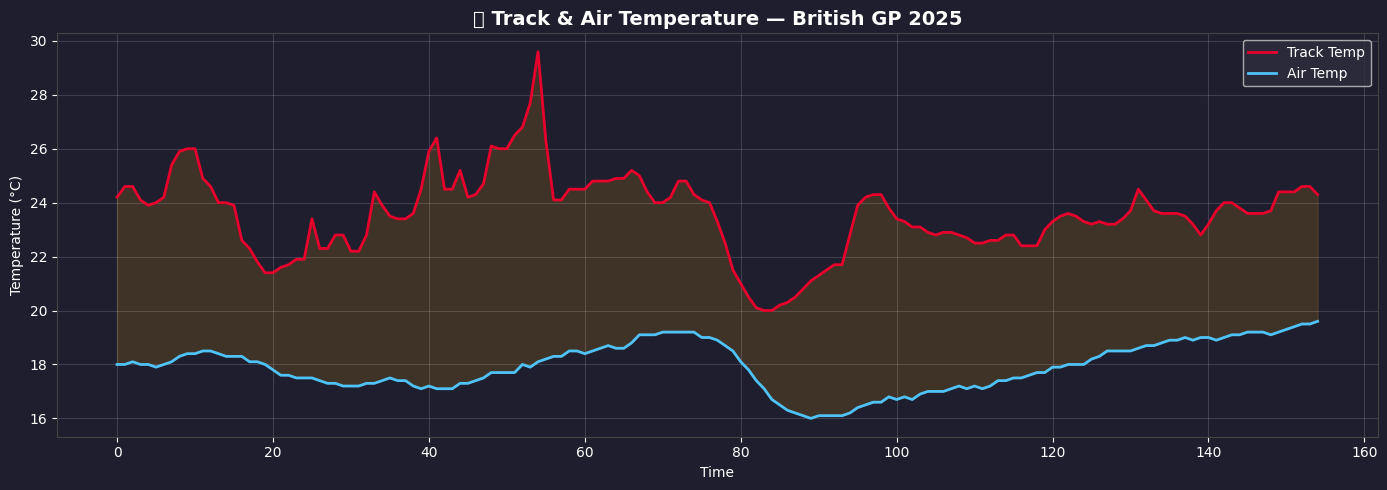

In [37]:
weather = session.weather_data

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor('#1e1e2e')
fig.patch.set_facecolor('#1e1e2e')

ax.plot(weather.index, weather['TrackTemp'], color='#e8002d', label='Track Temp', linewidth=2)
ax.plot(weather.index, weather['AirTemp'], color='#4fc3f7', label='Air Temp', linewidth=2)
ax.fill_between(weather.index, weather['AirTemp'], weather['TrackTemp'],
                alpha=0.15, color='orange')

ax.set_xlabel('Time', color='white')
ax.set_ylabel('Temperature (°C)', color='white')
ax.set_title('🌡️ Track & Air Temperature — British GP 2025', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
ax.legend(facecolor='#2e2e3e', labelcolor='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.grid(alpha=0.15, color='white')

plt.tight_layout()
plt.savefig('weather.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

# Position Changes Through the Race

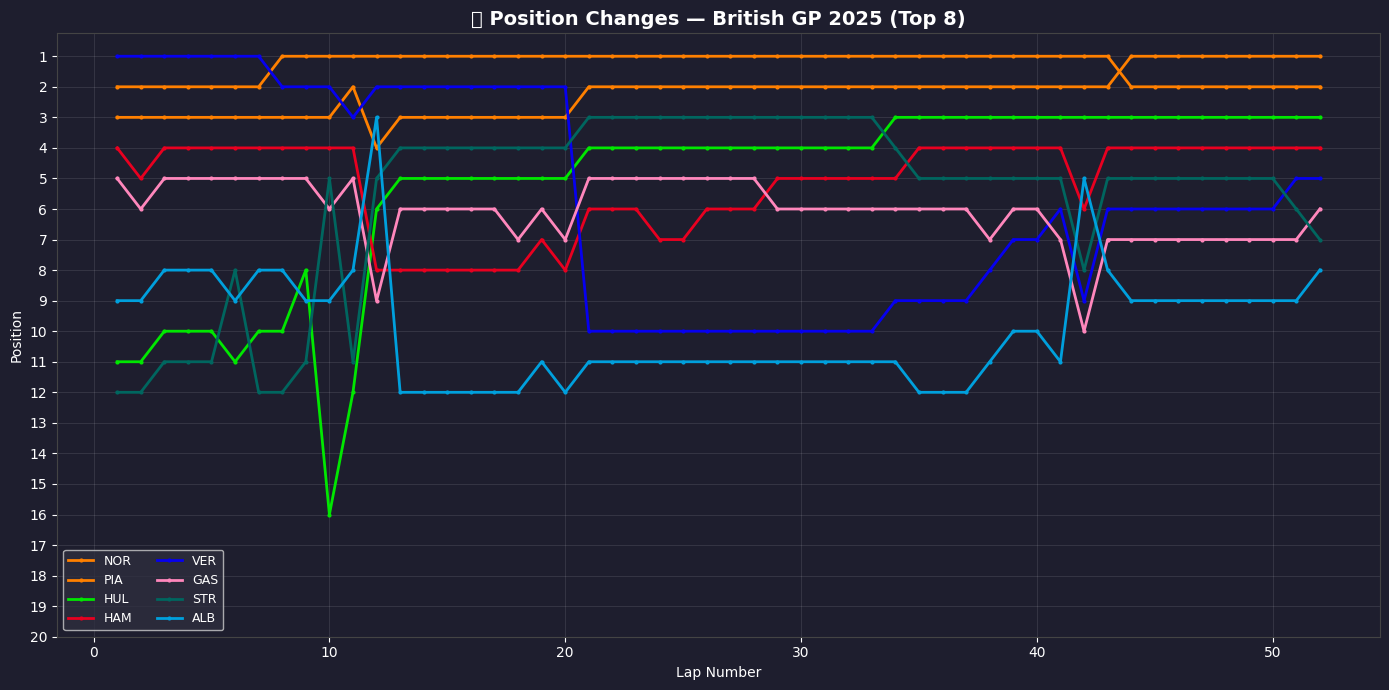

In [40]:
top8 = results.head(8)['Abbreviation'].tolist()
all_laps_pos = session.laps

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor('#1e1e2e')
fig.patch.set_facecolor('#1e1e2e')

for driver in top8:
    d_laps = all_laps_pos.pick_driver(driver)[['LapNumber', 'Position']].dropna()
    color = fastf1.plotting.get_driver_color(driver, session)
    ax.plot(d_laps['LapNumber'], d_laps['Position'], label=driver, color=color,
            linewidth=2, marker='o', markersize=2)

ax.invert_yaxis()
ax.set_yticks(range(1, 21))
ax.set_xlabel('Lap Number', color='white')
ax.set_ylabel('Position', color='white')
ax.set_title('📍 Position Changes — British GP 2025 (Top 8)', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
ax.legend(facecolor='#2e2e3e', labelcolor='white', fontsize=9, ncol=2)
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.grid(alpha=0.1, color='white')

plt.tight_layout()
plt.savefig('position_changes.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

# Throttle vs Brake - Winner's Fastest Lap

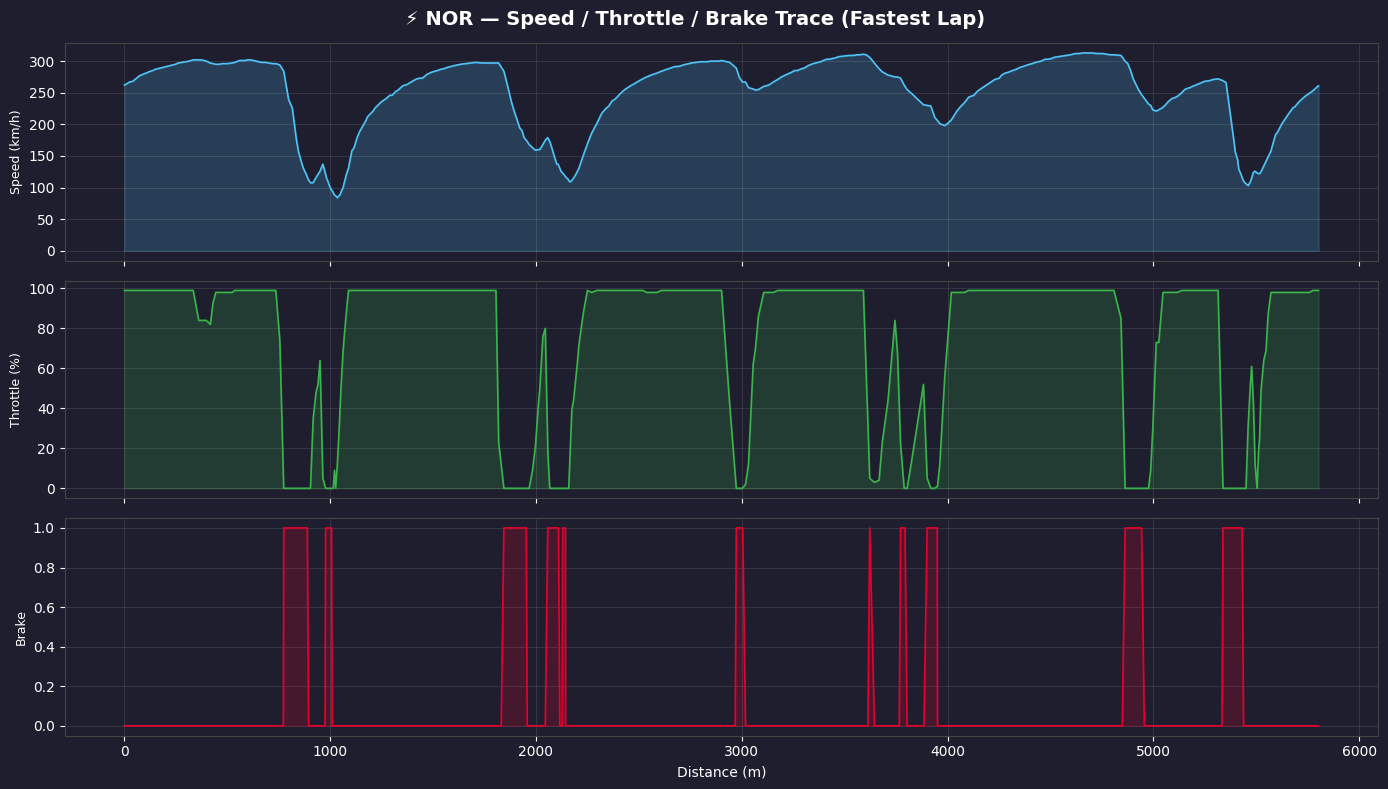

In [43]:
winner = results.iloc[0]['Abbreviation']
fast_lap = session.laps.pick_driver(winner).pick_fastest()
tel = fast_lap.get_telemetry()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor('#1e1e2e')

labels = ['Speed (km/h)', 'Throttle (%)', 'Brake']
cols   = ['Speed', 'Throttle', 'Brake']
colors = ['#4fc3f7', '#39b54a', '#e8002d']

for ax, col, label, color in zip(axes, cols, labels, colors):
    ax.set_facecolor('#1e1e2e')
    ax.plot(tel['Distance'], tel[col], color=color, linewidth=1.2)
    ax.fill_between(tel['Distance'], tel[col], alpha=0.2, color=color)
    ax.set_ylabel(label, color='white', fontsize=9)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
    ax.grid(alpha=0.1, color='white')

axes[-1].set_xlabel('Distance (m)', color='white')
fig.suptitle(f'⚡ {winner} — Speed / Throttle / Brake Trace (Fastest Lap)',
             color='white', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('throttle_brake.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

# Pit Stop Summary

In [46]:
print("Checking pit stop data...")
print(f"Total laps: {len(session.laps)}")
print(f"Laps with PitOutTime: {session.laps['PitOutTime'].notna().sum()}")
print(f"Laps with PitInTime: {session.laps['PitInTime'].notna().sum()}")

pit_data = session.laps[session.laps['PitOutTime'].notna()].copy()
if len(pit_data) > 0:
    print(f"\n✅ Found {len(pit_data)} pit stop records")
    print(pit_data[['Driver', 'LapNumber', 'PitInTime', 'PitOutTime']].head(10))
else:
    print("\n❌ No pit stop data in session.laps")
    print("Trying session results...")
    if hasattr(session, 'pit_stops'):
        print(session.pit_stops)

Checking pit stop data...
Total laps: 826
Laps with PitOutTime: 40
Laps with PitInTime: 36

✅ Found 40 pit stop records
    Driver  LapNumber PitInTime             PitOutTime
11     VER       12.0       NaT 0 days 01:17:52.088000
41     VER       42.0       NaT 0 days 02:17:11.002000
63     GAS       12.0       NaT 0 days 01:18:02.828000
93     GAS       42.0       NaT 0 days 02:17:12.127000
106    ANT        3.0       NaT 0 days 01:00:36.856000
113    ANT       10.0       NaT 0 days 01:14:43.467000
124    ANT       21.0       NaT 0 days 01:39:55.175000
138    ALO       12.0       NaT 0 days 01:18:03.719000
164    ALO       38.0       NaT 0 days 02:10:23.290000
179    LEC        1.0       NaT 0 days 00:56:24.191000


# 🏁 End of Analysis